In [2]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

/tmp/ipykernel_1324837/3005166470.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024/P_INPUT/Iceland3_grid.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300

model_bgc_dia_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"

variables_bgc_dia=['pH_3D','FG_CO2','FG_ALT_CO2','pCO2SURF','pCO2SURF_ALT_CO2']
variables_bgc=['ALK','ALK_ALT_CO2']

model_bgc_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc.202407????????.nc"

model_cstar_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_cstar.202407????????.nc"

target_depth_levels=[1,2,3,4,5,6,7,8,9,10,15] # Specify depth levels of interest
thinner=4 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


In [3]:
import xarray as xr
import numpy as np
import glob

# =========================
# Ensemble members
# =========================
ensembles = ["CDR1", "CDR2", "CDR3", "CDR4", "CDR5", "CDR6"]

N = vert_levels
theta_s = theta_s_model
theta_b = theta_b_model
hc = hc_model

# =========================
# Load grid (only once)
# =========================
grid = xr.open_dataset(model_grid_path)

h = grid["h"].values
mask_rho = grid["mask_rho"].values.astype(bool)

eta, xi = h.shape

# =========================
# Vertical coordinates
# =========================
k_w = np.linspace(0, N, N + 1)
sigma_w = (k_w - N) / N


def Cs(sigma, theta_s, theta_b):
    C = (1 - np.cosh(theta_s * sigma)) / (np.cosh(theta_s) - 1)
    C = (np.exp(theta_b * C) - 1) / (1 - np.exp(-theta_b))
    return C


Cs_w = Cs(sigma_w, theta_s, theta_b)

sigma_w_3d = sigma_w[:, None, None]
Cs_w_3d = Cs_w[:, None, None]
h_3d = h[None, :, :]

S_w = (hc * sigma_w_3d + h_3d * Cs_w_3d) / (hc + h_3d)

# =========================
# Loop over ensembles
# =========================
for ens in ensembles:

    #print(f"\nProcessing ensemble {ens}")

    his_path = f"/home/x-uheede/S/Iceland3_MARBL_2024_{ens}/Iceland3_MARBL_2024_his.202407*.nc"

    ds = xr.open_mfdataset(
        his_path,
        combine='nested',
        concat_dim=["time"]
    )

    zeta = ds["zeta"]

    thickness_list = []

    for t in range(len(zeta.time)):

        #print(f"{ens} time {t+1}/{len(zeta.time)}")

        zeta_t = zeta.isel(time=t).values

        zeta_3d = zeta_t[None, :, :]

        z_w = zeta_3d + (zeta_3d + h_3d) * S_w

        thickness = np.diff(z_w, axis=0)

        thickness[:, ~mask_rho] = np.nan

        thickness_list.append(thickness)

    thickness_all = np.stack(thickness_list, axis=0)

    # =========================
    # Save as xarray
    # =========================
    thickness_da = xr.DataArray(
        thickness_all,
        dims=["time", "s_rho", "eta_rho", "xi_rho"],
        coords={
            "time": ds.time,
            "s_rho": np.arange(N),
            "eta_rho": ds.eta_rho,
            "xi_rho": ds.xi_rho,
        },
        name="cell_thickness"
    )

    out_file = f"Iceland3_cell_thickness_July2024_{ens}.nc"

    thickness_da.to_netcdf(out_file)

    print(f"Saved {out_file}")

print("\nAll ensembles processed")

KeyboardInterrupt: 

In [3]:
import xarray as xr
import numpy as np

# =========================
# Paths
# =========================
bgc_paths = {
    ens: f"/anvil/scratch/x-uheede/Iceland3_MARBL_2024_{ens}/Iceland3_MARBL_2024_bgc.202407*.nc"
    for ens in ensembles
}

thickness_files = {
    ens: f"Iceland3_cell_thickness_July2024_{ens}.nc"
    for ens in ensembles
}

# =========================
# Grid
# =========================
grid = xr.open_dataset(model_grid_path)

pm = grid["pm"]
pn = grid["pn"]

area = 1 / (pm * pn)  # m2

# =========================
# Storage
# =========================
total_alk_timeseries = {}
surface_alk_fraction = {}

# =========================
# Loop over ensembles
# =========================
for ens in ensembles:

    print(f"\nProcessing {ens}")

    ds_bgc = xr.open_mfdataset(
        bgc_paths[ens],
        combine="nested",
        concat_dim="time"
    )

    ALK = ds_bgc["ALK"] - ds_bgc["ALK_ALT_CO2"]
    thickness = xr.open_dataset(thickness_files[ens])["cell_thickness"]

    volume = thickness * area

    total_alk = (ALK * volume).sum(
        dim=["s_rho", "eta_rho", "xi_rho"],
        skipna=True
    )
    total_alk_timeseries[ens] = total_alk

    ALK_surface = ALK.isel(s_rho=slice(58, 60))
    volume_surface = volume.isel(s_rho=slice(58, 60))

    surface_alk = (ALK_surface * volume_surface).sum(
        dim=["s_rho", "eta_rho", "xi_rho"],
        skipna=True
    )

    surface_alk_fraction[ens] = surface_alk / total_alk

    print("done")


Processing CDR1
done

Processing CDR2
done

Processing CDR3
done


In [12]:
# =========================
# Convert dictionaries to Dataset
# =========================
ds_out = xr.Dataset()

for ens in ensembles:

    total_ts = total_alk_timeseries[ens]
    surface_ts = surface_alk_fraction[ens]

    # Apply same time shift used in plotting
    if ens == "CDR1":
        total_ts = total_ts.copy()
        surface_ts = surface_ts.copy()
        surface_ts["time"] = surface_ts["time"] + 34

    ds_out[f"total_alk_{ens}"] = total_ts
    ds_out[f"surface_fraction_{ens}"] = surface_ts

# =========================
# Add metadata
# =========================
for ens in ensembles:
    ds_out[f"total_alk_{ens}"].attrs["units"] = "mol"
    ds_out[f"surface_fraction_{ens}"].attrs["units"] = "fraction"

ds_out.attrs["description"] = "Total alkalinity inventory and surface fraction (s_rho 58-59)"
ds_out.attrs["model"] = "Iceland3 MARBL July 2024"
ds_out.attrs["created_by"] = "ALK inventory calculation script"

# =========================
# Save NetCDF
# =========================
ds_out.to_netcdf("Iceland3_total_alk_and_surface_fraction.nc")

print("NetCDF saved: Iceland3_total_alk_and_surface_fraction.nc")

NetCDF saved: Iceland3_total_alk_and_surface_fraction.nc


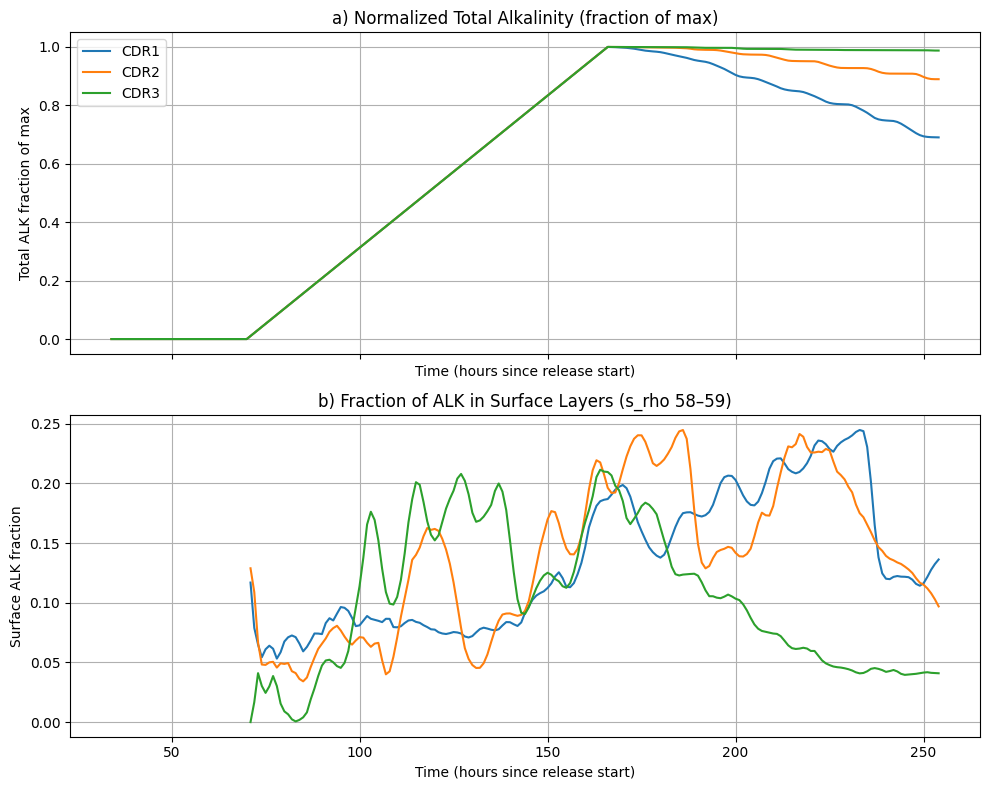

In [5]:
# Plotting has been moved to oae_analysis.ipynb.
# This notebook is reserved for generating NetCDF products consumed by plotting.

In [8]:
ts

<xarray.DataArray (time: 221)> Size: 2kB
dask.array<sum-aggregate, shape=(221,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 2kB 34 35 36 37 38 39 40 ... 249 250 251 252 253 254

In [ ]:
from roms_tools import Grid, ROMSOutput

grid = Grid.from_file(
    model_grid_path
)

#Only run this cell if grid is made in MATLAB
grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)


In [ ]:
import xarray as xr
import numpy as np

# -----------------------------------
# Group paths
# -----------------------------------
path_dict = {
    "bgc": [
        model_bgc_path1,
        model_bgc_path2,
        model_bgc_path3,
    ]
}

# -----------------------------------
# Variable lists
# -----------------------------------
var_dict = {
    "bgc": variables_bgc
}

# -----------------------------------
# Loop and create roms_* and ds_* variables
# -----------------------------------
for key, paths in path_dict.items():

    for i, path in enumerate(paths, start=1):

        # Create ROMSOutput object
        roms_obj = ROMSOutput(
            grid=grid,
            path=[path],
            use_dask=True
        )

        # Assign roms_* variable (e.g., roms_bgc1)
        globals()[f"roms_{key}{i}"] = roms_obj

        # Regrid
        if var_dict[key] is not None:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels,
                var_names=var_dict[key]
            )
        else:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels
            )

        # Assign ds_* variable (e.g., ds_bgc1)
        globals()[f"ds_{key}{i}"] = ds

In [ ]:
def get_start_time(ds, threshold=1e-6):

    diff = ds["ALK"].isel(depth=0) - ds["ALK_ALT_CO2"].isel(depth=0)

    # boolean signal over domain
    signal = (np.abs(diff) > threshold).any(dim=("lat", "lon"))

    # compute only the 1D signal
    signal = signal.compute()

    # first time where signal appears
    t0 = ds.time.sel(time=signal).min()

    return t0


def add_relative_time(ds, t0):

    time_rel = (ds.time - t0) / np.timedelta64(1, "h")

    return ds.assign_coords(time_rel=("time", time_rel.data))

# Compute start times
t0_1 = get_start_time(ds_bgc1)
t0_2 = get_start_time(ds_bgc2)
t0_3 = get_start_time(ds_bgc3)

# Add relative time

ds_bgc1 = add_relative_time(ds_bgc1, t0_1)
ds_bgc2 = add_relative_time(ds_bgc2, t0_2)
ds_bgc3 = add_relative_time(ds_bgc3, t0_3)



ds_bgc1 = ds_bgc1.swap_dims({"time": "time_rel"})
ds_bgc2 = ds_bgc2.swap_dims({"time": "time_rel"})
ds_bgc3 = ds_bgc3.swap_dims({"time": "time_rel"})

time_rel_common = np.arange(-48, 240, 1)  # hours

ds_bgc1 = ds_bgc1.interp(time_rel=time_rel_common)
ds_bgc2 = ds_bgc2.interp(time_rel=time_rel_common)
ds_bgc3 = ds_bgc3.interp(time_rel=time_rel_common)



In [ ]:
import numpy as np
import xarray as xr
from roms_tools import ROMSOutput

# NetCDF generation block used by oae_analysis.ipynb.

variables_bgc_full = ["ALK", "ALK_ALT_CO2", "DIC", "DIC_ALT_CO2"]
variables_bgc_dia_full = ["pH_3D", "FG_CO2", "FG_ALT_CO2", "pCO2SURF", "pCO2SURF_ALT_CO2"]
variables_cstar = ["hDIC_sum", "hDIC_ALT_CO2_sum", "FG_CO2", "FG_ALT_CO2"]

bgc_paths = [
    model_bgc_path1,
    model_bgc_path2,
    model_bgc_path3,
    model_bgc_path4,
    model_bgc_path5,
    model_bgc_path6,
]
bgc_dia_paths = [
    model_bgc_dia_path1,
    model_bgc_dia_path2,
    model_bgc_dia_path3,
    model_bgc_dia_path4,
    model_bgc_dia_path5,
    model_bgc_dia_path6,
]
cstar_paths = [
    model_cstar_path1,
    model_cstar_path2,
    model_cstar_path3,
    model_cstar_path4,
    model_cstar_path5,
    model_cstar_path6,
]
ens_labels = ["CDR1", "CDR2", "CDR3", "CDR4", "CDR5", "CDR6"]


def remove_duplicate_time(ds):
    _, index = np.unique(ds["time"], return_index=True)
    return ds.isel(time=index)


def get_start_time(ds, threshold=1e-6):
    diff = ds["ALK"].isel(depth=0).load() - ds["ALK_ALT_CO2"].isel(depth=0).load()
    signal = diff.max(dim=("lat", "lon"))
    return signal.where(signal > threshold, drop=True).time.min()


def add_relative_time(ds, t0):
    time_rel = (ds.time - t0) / np.timedelta64(1, "h")
    return ds.assign_coords(time_rel=("time", time_rel.data))


ds_bgc_list = []
ds_bgc_dia_list = []
ds_cstar_list = []

for i, (bgc_path, bgc_dia_path, cstar_path) in enumerate(zip(bgc_paths, bgc_dia_paths, cstar_paths), start=1):
    roms_bgc = ROMSOutput(grid=grid, path=[bgc_path], use_dask=True)
    roms_bgc_dia = ROMSOutput(grid=grid, path=[bgc_dia_path], use_dask=True)
    roms_cstar = ROMSOutput(grid=grid, path=[cstar_path], use_dask=True)

    ds_bgc = roms_bgc.regrid(depth_levels=target_depth_levels, var_names=variables_bgc_full)
    ds_bgc_dia = roms_bgc_dia.regrid(depth_levels=target_depth_levels, var_names=variables_bgc_dia_full)

    ds_cstar = roms_cstar.ds
    ds_cstar["hDIC_sum"] = ds_cstar["hDIC"].sum(dim="s_rho", skipna=True)
    ds_cstar["hDIC_ALT_CO2_sum"] = ds_cstar["hDIC_ALT_CO2"].sum(dim="s_rho", skipna=True)
    roms_cstar.ds = ds_cstar
    ds_cstar_rg = roms_cstar.regrid(depth_levels=target_depth_levels, var_names=variables_cstar)

    ds_bgc = remove_duplicate_time(ds_bgc)
    ds_bgc_dia = remove_duplicate_time(ds_bgc_dia)
    ds_cstar = remove_duplicate_time(ds_cstar)

    t0 = get_start_time(ds_bgc)

    ds_bgc = add_relative_time(ds_bgc, t0).swap_dims({"time": "time_rel"})
    ds_bgc_dia = add_relative_time(ds_bgc_dia, t0).swap_dims({"time": "time_rel"})
    ds_cstar = add_relative_time(ds_cstar, t0).swap_dims({"time": "time_rel"})

    time_rel_common = np.arange(-48, 240, 1)
    ds_bgc = ds_bgc.interp(time_rel=time_rel_common)
    ds_bgc_dia = ds_bgc_dia.interp(time_rel=time_rel_common)
    ds_cstar = ds_cstar.interp(time_rel=time_rel_common)

    ds_bgc_list.append(ds_bgc)
    ds_bgc_dia_list.append(ds_bgc_dia)
    ds_cstar_list.append(ds_cstar)

    ds_cstar_rg.to_netcdf(f"ds_cstar{i}_regridded.nc")

    ds_cdr = roms_cstar.cdr_metrics()
    roms_cstar.ds_cdr.to_netcdf(f"Iceland3_CDR{i}_cdr_metrics.nc")


ds_bgc_ens = xr.concat(ds_bgc_list, dim="ens")
ds_bgc_dia_ens = xr.concat(ds_bgc_dia_list, dim="ens")
ds_cstar_ens = xr.concat(ds_cstar_list, dim="ens")

for ds in [ds_bgc_ens, ds_bgc_dia_ens, ds_cstar_ens]:
    ds["ens"] = ens_labels

# Max surface ALK and pCO2 diagnostics
ALK_anom = ds_bgc_ens["ALK"] - ds_bgc_ens["ALK_ALT_CO2"]
max_ALK_surface = ALK_anom.isel(depth=0).max(dim=["lat", "lon"], skipna=True)

xr.Dataset({"max_ALK_surface_anom": max_ALK_surface.load()}).to_netcdf("Iceland3_max_surface_alk.nc")

pCO2_surface = ds_bgc_dia_ens["pCO2SURF"]
max_pCO2_surface = pCO2_surface.min(dim=["lat", "lon"], skipna=True)
xr.Dataset({"max_pCO2SURF": max_pCO2_surface.load()}).to_netcdf("Iceland3_max_surface_pCO2.nc")

# Extrema metrics
pCO2SURF_anom = ds_bgc_dia_ens["pCO2SURF"] - ds_bgc_dia_ens["pCO2SURF_ALT_CO2"]
PH_anom = ds_bgc_dia_ens["pH_3D"]
DIC_anom = ds_bgc_ens["DIC"] - ds_bgc_ens["DIC_ALT_CO2"]

min_pCO2SURF = pCO2SURF_anom.min(dim=["lat", "lon"], skipna=True)
max_PH = PH_anom.max(dim=["depth", "lat", "lon"], skipna=True)
max_ALK = ALK_anom.max(dim=["depth", "lat", "lon"], skipna=True)
max_DIC = DIC_anom.max(dim=["depth", "lat", "lon"], skipna=True)

xr.Dataset(
    {
        "min_pCO2SURF_anom": min_pCO2SURF.load(),
        "max_PH_anom": max_PH.load(),
        "max_ALK_anom": max_ALK.load(),
        "max_ALK_surface_anom": max_ALK_surface.load(),
        "max_DIC_anom": max_DIC.load(),
    }
).to_netcdf("Iceland3_CDR_extrema_metrics.nc")

# 0-96 h mean anomaly fields at 1 m
time_sel_dia = ds_bgc_dia_ens.sel(time_rel=slice(0, 96))
time_sel_bgc = ds_bgc_ens.sel(time_rel=slice(0, 96))

pCO2SURF_mean = (time_sel_dia["pCO2SURF"] - time_sel_dia["pCO2SURF_ALT_CO2"]).mean(dim="time_rel", skipna=True).load()
PH_mean = time_sel_dia["pH_3D"].sel(depth=1, method="nearest").mean(dim="time_rel", skipna=True).load()
ALK_mean = (time_sel_bgc["ALK"] - time_sel_bgc["ALK_ALT_CO2"]).sel(depth=1, method="nearest").mean(dim="time_rel", skipna=True).load()
DIC_mean = (time_sel_bgc["DIC"] - time_sel_bgc["DIC_ALT_CO2"]).sel(depth=1, method="nearest").mean(dim="time_rel", skipna=True).load()

encoding = {"zlib": True, "complevel": 4}
pCO2SURF_mean.to_netcdf("Iceland3_pCO2SURF_1m_time0_96_mean.nc")
PH_mean.to_netcdf("Iceland3_PH_1m_time0_96_mean.nc", encoding={"pH_3D": encoding})
ALK_mean.to_netcdf("Iceland3_ALK_1m_time0_96_mean.nc", encoding={"ALK": encoding})
DIC_mean.to_netcdf("Iceland3_DIC_1m_time0_96_mean.nc", encoding={"DIC": encoding})

# Cumulative CSTAR fields
FG_anom = ds_cstar_ens["FG_CO2"] - ds_cstar_ens["FG_ALT_CO2"]
hDIC_anom = ds_cstar_ens["hDIC"] - ds_cstar_ens["hDIC_ALT_CO2"]

xr.Dataset(
    {
        "FG_CO2_cumsum_anom": FG_anom.cumsum(dim="time_rel").load(),
        "hDIC_anom": hDIC_anom.load(),
    }
).to_netcdf("Iceland3_CDR_cstar_cumsum_fields.nc")

print("Saved all NetCDF products needed by oae_analysis plotting")

In [ ]:
# Plotting moved to oae_analysis.ipynb

In [ ]:
# Plotting moved to oae_analysis.ipynb

In [ ]:
# Plotting moved to oae_analysis.ipynb


In [ ]:
# Plotting moved to oae_analysis.ipynb


In [ ]:
# Plotting moved to oae_analysis.ipynb

In [ ]:
# Plotting moved to oae_analysis.ipynb

In [ ]:
# Plotting moved to oae_analysis.ipynb

In [ ]:
# Plotting moved to oae_analysis.ipynb